# Klasifikasi Rimpang — COMPARE
Menggabungkan dan membandingkan hasil semua eksperimen.

> ⚠️ **Jalankan file ini terakhir**, setelah semua notebook eksperimen sudah dijalankan.

In [6]:
# Cell 1 — Import
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Import berhasil')

Import berhasil


In [7]:
# Cell 2 — Baca semua hasil CSV
EXP_NAMES = ['Baseline', 'P1_Grayscale', 'P2_CLAHE', 'P3_Blur_CLAHE', 'P4_Median_CLAHE']

all_results = []
for exp in EXP_NAMES:
    path = f'output/hasil_{exp}.csv'
    if os.path.exists(path):
        all_results.append(pd.read_csv(path))
        print(f'[OK] {path}')
    else:
        print(f'[MISSING] {path}')

df_all = pd.concat(all_results, ignore_index=True)
df_all.to_csv('output/hasil_perbandingan_semua.csv', index=False)
print(f'\nTotal: {len(df_all)} baris')
print(df_all.to_string(index=False))

[OK] output/hasil_Baseline.csv
[OK] output/hasil_P1_Grayscale.csv
[OK] output/hasil_P2_CLAHE.csv
[OK] output/hasil_P3_Blur_CLAHE.csv
[OK] output/hasil_P4_Median_CLAHE.csv

Total: 15 baris
     Eksperimen Model  Akurasi
       Baseline   KNN    51.59
       Baseline   SVM    55.56
       Baseline    RF    57.14
   P1_Grayscale   KNN    47.62
   P1_Grayscale   SVM    50.79
   P1_Grayscale    RF    51.59
       P2_CLAHE   KNN    53.97
       P2_CLAHE   SVM    59.52
       P2_CLAHE    RF    57.14
  P3_Blur_CLAHE   KNN    46.83
  P3_Blur_CLAHE   SVM    51.59
  P3_Blur_CLAHE    RF    57.14
P4_Median_CLAHE   KNN    46.03
P4_Median_CLAHE   SVM    50.79
P4_Median_CLAHE    RF    47.62


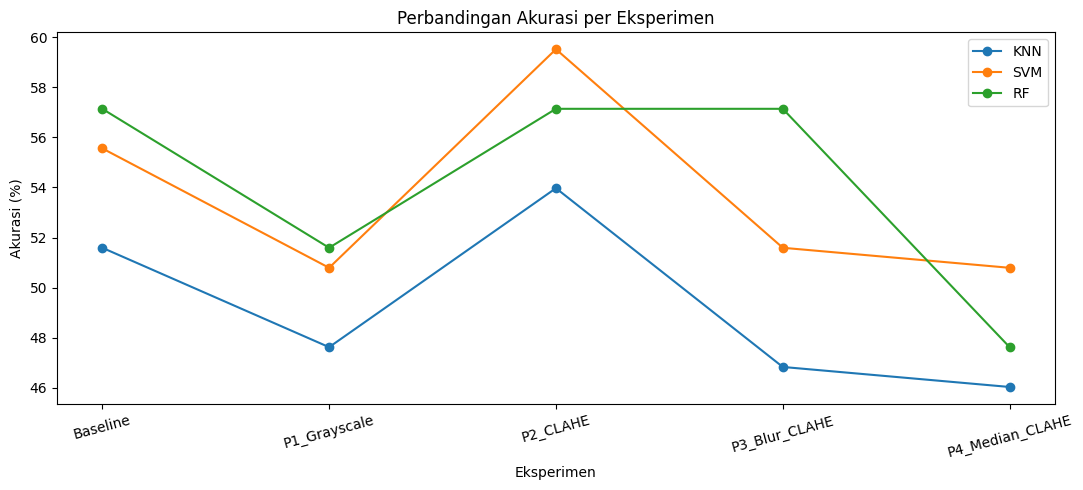

Disimpan ke output/grafik_perbandingan.png


In [8]:
# Cell 3 — Grafik line perbandingan
plt.figure(figsize=(11, 5))
for model_name in ['KNN', 'SVM', 'RF']:
    subset = df_all[df_all['Model'] == model_name]
    plt.plot(subset['Eksperimen'], subset['Akurasi'], marker='o', label=model_name)

plt.title('Perbandingan Akurasi per Eksperimen')
plt.ylabel('Akurasi (%)')
plt.xlabel('Eksperimen')
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('output/grafik_perbandingan.png', dpi=150)
plt.show()
print('Disimpan ke output/grafik_perbandingan.png')

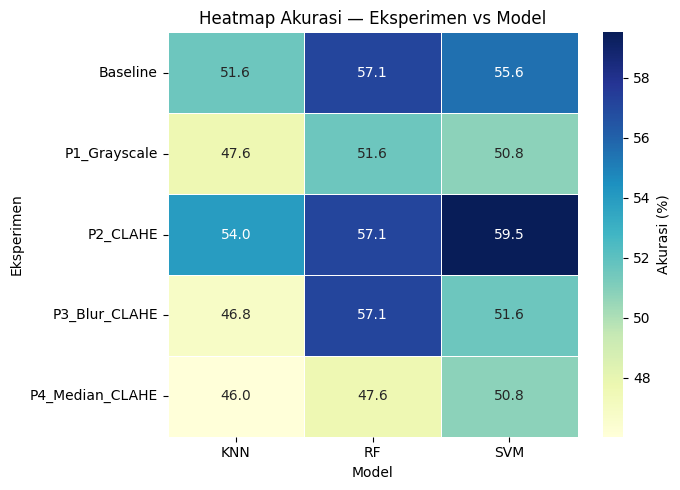

Disimpan ke output/heatmap_perbandingan.png


In [9]:
# Cell 4 — Heatmap akurasi
pivot = df_all.pivot(index='Eksperimen', columns='Model', values='Akurasi').reindex(EXP_NAMES)

plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Akurasi (%)'})
plt.title('Heatmap Akurasi — Eksperimen vs Model')
plt.tight_layout()
plt.savefig('output/heatmap_perbandingan.png', dpi=150)
plt.show()
print('Disimpan ke output/heatmap_perbandingan.png')

In [10]:
# Cell 5 — Ringkasan
best = df_all.loc[df_all['Akurasi'].idxmax()]
print('=== HASIL TERBAIK ===')
print(f'Eksperimen : {best["Eksperimen"]}')
print(f'Model      : {best["Model"]}')
print(f'Akurasi    : {best["Akurasi"]}%')

print('\n=== RATA-RATA PER EKSPERIMEN ===')
print(df_all.groupby('Eksperimen')['Akurasi'].mean().reindex(EXP_NAMES).round(2).to_string())

print('\n=== RATA-RATA PER MODEL ===')
print(df_all.groupby('Model')['Akurasi'].mean().round(2).to_string())

=== HASIL TERBAIK ===
Eksperimen : P2_CLAHE
Model      : SVM
Akurasi    : 59.52%

=== RATA-RATA PER EKSPERIMEN ===
Eksperimen
Baseline           54.76
P1_Grayscale       50.00
P2_CLAHE           56.88
P3_Blur_CLAHE      51.85
P4_Median_CLAHE    48.15

=== RATA-RATA PER MODEL ===
Model
KNN    49.21
RF     54.13
SVM    53.65
